# Hands On 2
## Mesin Prediksi & Continual Learning untuk Risk Score

Notebook ini melanjutkan langsung dari Hands-On 1. Di HO1, dataset `features_labels.csv`
dibentuk: satu baris per unit analisis (sel grid 150 m × hari × jam) berisi fitur ruang–waktu
dan label `risk_score` (0–100) hasil *pseudo-labeling* (severity scoring berbasis hukum Illinois,
temporal decay half-life 180 hari, spatial decay Gaussian σ=150 m, dan normalisasi logaritmik).


# 0. Setup

In [1]:
!pip install -q scikit-learn scipy joblib pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, json, warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
np.random.seed(42)
print("Setup selesai")

Setup selesai


# 1. Load Dataset Fitur + Label dari Hands-On 1

Dataset akhir HO1: 374.790 baris × 20 kolom (19 fitur + 1 label), tanpa nilai kosong.
`risk_score` berdistribusi menyerupai normal (rata-rata ≈ 37,9; median ≈ 38,4; std ≈ 16,9),
konsekuensi dari normalisasi logaritmik di HO1 , menguntungkan untuk regresi.

In [3]:
DATA_PATH = "features_labels.csv"   # upload file HO1 ke session ini

df = pd.read_csv(DATA_PATH)
print(f"Dataset HO1 dimuat: {df.shape}")
print("Kolom:", list(df.columns))
print("\nNaN:", int(df.isna().sum().sum()), "| cell_id unik:", df["cell_id"].nunique())
df.head()

Dataset HO1 dimuat: (374790, 20)
Kolom: ['cell_id', 'gx', 'gy', 'lat_r', 'lon_r', 'dow', 'hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'n_crimes', 'mean_severity', 'max_severity', 'pct_violent', 'n_distinct_types', 'density_ratio', 'crime_count', 'risk_score']

NaN: 0 | cell_id unik: 19863


,cell_id,gx,gy,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,n_crimes,mean_severity,max_severity,pct_violent,n_distinct_types,density_ratio,crime_count,risk_score
0,-48387_30944,-48387,30944,41.696685,-87.52373,0,1,0.258819,0.965926,0.000000,1.000000,0,6,44.5,77,16.666667,5,0.250384,1,40.439362
1,-48387_30944,-48387,30944,41.696685,-87.52373,0,20,-0.866025,0.500000,0.000000,1.000000,0,6,44.5,77,16.666667,5,0.250384,1,27.221181
2,-48387_30944,-48387,30944,41.696685,-87.52373,1,2,0.500000,0.866025,0.781831,0.623490,0,6,44.5,77,16.666667,5,0.250384,1,17.555134
3,-48387_30944,-48387,30944,41.696685,-87.52373,1,8,0.866025,-0.500000,0.781831,0.623490,0,6,44.5,77,16.666667,5,0.250384,1,7.725378
4,-48387_30944,-48387,30944,41.696685,-87.52373,3,22,-0.500000,0.866025,0.433884,-0.900969,0,6,44.5,77,16.666667,5,0.250384,1,26.102106


In [4]:
df.describe().round(2)

,gx,gy,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,n_crimes,mean_severity,max_severity,pct_violent,n_distinct_types,density_ratio,crime_count,risk_score
count,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00,374790.00
mean,-48467.49,31053.32,41.84,-87.67,3.02,12.47,-0.15,-0.02,-0.01,-0.00,0.29,61.50,39.16,86.80,38.27,8.69,2.57,1.27,37.89
std,32.62,65.14,0.09,0.06,2.00,6.94,0.67,0.72,0.71,0.71,0.45,79.62,6.88,16.43,17.37,2.92,3.32,0.82,16.88
min,-48614.00,30905.00,41.64,-87.93,0.00,0.00,-1.00,-1.00,-0.97,-0.90,0.00,1.00,10.00,10.00,0.00,1.00,0.04,1.00,0.00
25%,-48490.00,30998.00,41.77,-87.71,1.00,7.00,-0.87,-0.71,-0.78,-0.90,0.00,19.00,34.56,82.00,26.32,7.00,0.79,1.00,25.53
50%,-48464.00,31063.00,41.86,-87.66,3.00,13.00,-0.26,-0.00,0.00,-0.22,0.00,37.00,39.52,95.00,39.58,9.00,1.54,1.00,38.45
75%,-48444.00,31102.00,41.91,-87.63,5.00,18.00,0.50,0.71,0.78,0.62,1.00,74.00,43.76,100.00,50.00,11.00,3.09,1.00,50.22
max,-48387.00,31186.00,42.02,-87.52,6.00,23.00,1.00,1.00,0.97,1.00,1.00,1162.00,100.00,100.00,100.00,18.00,48.49,56.00,100.00


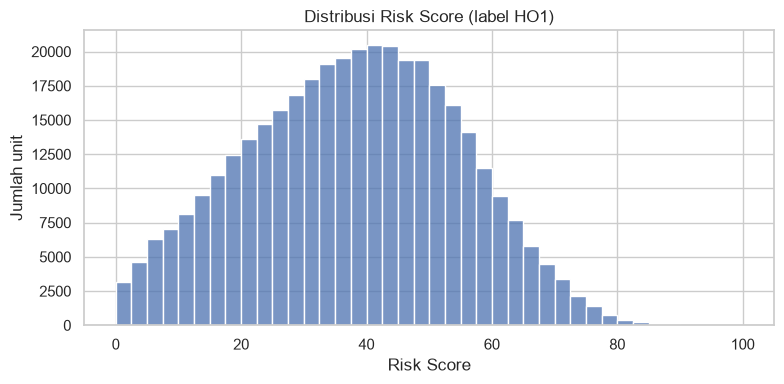

In [5]:
plt.figure(figsize=(8,4))
sns.histplot(df["risk_score"], bins=40, color="#4C72B0")
plt.title("Distribusi Risk Score (label HO1)")
plt.xlabel("Risk Score"); plt.ylabel("Jumlah unit")
plt.tight_layout(); plt.show()

# 2. Baseline Non-ML

Baseline adalah patokan minimal sebelum melatih model apa pun: apakah model ML benar-benar
memberi nilai tambah dibanding aturan sederhana? Selain tiga baseline tutorial (mean global,
per-sel, per-(hari,jam)), saya menambahkan dua baseline kombinasi dengan *fallback* berjenjang
, justru untuk menunjukkan bahwa "lebih kompleks" tidak selalu "lebih baik".

In [6]:
TARGET_COL = "risk_score"
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True); test_df = test_df.reset_index(drop=True)
print(f"train_df: {train_df.shape} | test_df: {test_df.shape}")

def evaluate(y_true, y_pred, label):
    return {"model": label,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2": r2_score(y_true, y_pred)}

train_df: (299832, 20) | test_df: (74958, 20)


In [7]:
results = []
gmean = train_df[TARGET_COL].mean()

# 1) global mean
results.append(evaluate(test_df[TARGET_COL], np.full(len(test_df), gmean), "Baseline: Global Mean"))

# 2) per-sel (pola spasial)
cell_map = train_df.groupby("cell_id")[TARGET_COL].mean()
pred_cell = test_df["cell_id"].map(cell_map).fillna(gmean).values
results.append(evaluate(test_df[TARGET_COL], pred_cell, "Baseline: per-Sel"))

# 3) per-(hari,jam) (pola temporal)
hd_map = train_df.groupby(["dow","hour"])[TARGET_COL].mean()
idx = pd.MultiIndex.from_frame(test_df[["dow","hour"]])
p = hd_map.reindex(idx).values; p = np.where(np.isnan(p), gmean, p)
results.append(evaluate(test_df[TARGET_COL], p, "Baseline: per-(hari,jam)"))

# 4) kombinasi per-(sel,jam) + fallback: (sel,jam) -> sel -> global
ch_map = train_df.groupby(["cell_id","hour"])[TARGET_COL].mean()
idx = pd.MultiIndex.from_frame(test_df[["cell_id","hour"]])
p_ch = ch_map.reindex(idx).values
p = np.where(np.isnan(p_ch), np.where(np.isnan(pred_cell), gmean, pred_cell), p_ch)
results.append(evaluate(test_df[TARGET_COL], p, "Baseline: per-(sel,jam)+fallback"))

# 5) kombinasi per-(sel,hari,jam) + fallback berjenjang
cdh_map = train_df.groupby(["cell_id","dow","hour"])[TARGET_COL].mean()
idx = pd.MultiIndex.from_frame(test_df[["cell_id","dow","hour"]])
p_cdh = cdh_map.reindex(idx).values
p = np.where(np.isnan(p_cdh),
            np.where(np.isnan(p_ch), np.where(np.isnan(pred_cell), gmean, pred_cell), p_ch),
            p_cdh)
results.append(evaluate(test_df[TARGET_COL], p, "Baseline: per-(sel,hari,jam)+fallback"))

baseline_results_df = pd.DataFrame(results).round(3)
baseline_results_df

,model,MAE,RMSE,R2
0,Baseline: Global Mean,13.896,16.903,-0.000
1,Baseline: per-Sel,12.190,15.139,0.198
2,"Baseline: per-(hari,jam)",13.691,16.674,0.027
3,"Baseline: per-(sel,jam)+fallback",13.713,17.261,-0.043
4,"Baseline: per-(sel,hari,jam)+fallback",13.713,17.261,-0.043


Analisis baseline.
- Baseline per-Sel adalah yang terkuat (MAE ≈ 12,19; R² ≈ 0,198). Ini konsisten dengan temuan
  HO1 bahwa kejahatan terkonsentrasi secara spasial: "lokasi ini secara historis seberapa rawan"
  membawa sinyal terkuat.
- Pola temporal murni sangat lemah (per-(hari,jam), R² ≈ 0,03). Sesuai temuan EDA HO1: distribusi
  antar hari nyaris seragam, dan efek jam baru bermakna ketika berinteraksi dengan lokasi.
- Kombinasi malah memburuk (per-(sel,jam) dan per-(sel,hari,jam) -> R² ≈ −0,04, lebih buruk dari
  mean global). Penyebabnya kelangkaan data: median hanya 12 baris/sel (HO1), tersebar pada
  7×24 = 168 slot (hari,jam), sehingga sebagian besar kombinasi hanya punya <1 baris training ->
  "rata-rata" yang dihafal hanyalah noise satu observasi. Ini pelajaran penting: *granularitas
  lookup table dibatasi oleh kepadatan data, bukan oleh imajinasi kita*. Justru inilah alasan kita
  butuh model yang menggeneralisasi lewat fitur, bukan menghafal kombinasi.
- Strategi fallback: memakai rantai (sel,hari,jam) -> (sel,jam) -> (sel) -> global. Namun karena
  level terhalus terlalu langka, fallback praktis selalu jatuh ke level (sel). Kesimpulannya, per-Sel
  sudah menjadi *fallback* yang paling stabil , dan itulah baseline yang saya jadikan pembanding utama.

# 3. Feature Vector Assembly

Semua fitur dirakit lewat satu fungsi `assemble_features` agar representasi saat training identik
dengan saat serving di final project. Keputusan utama saya berbeda dari baseline tutorial:

- Memakai seluruh 14 fitur numerik, termasuk 6 fitur agregat spasial HO1 yang dibuang tutorial
  (`n_crimes, mean_severity, max_severity, pct_violent, n_distinct_types, density_ratio`). Alasannya
  empiris: korelasi fitur-fitur ini terhadap `risk_score` (0,18–0,35) jauh lebih tinggi daripada
  koordinat mentah (`lon_r` 0,12) , membuangnya berarti membuang sinyal terkuat yang sudah susah
  payah dibangun di HO1.
- Target encoding untuk `cell_id` (high-cardinality). Untuk menghindari *data leakage*, statistik
  rata-rata per sel dihitung hanya dari data train, dengan *smoothing* ke arah mean global agar
  sel berdata tipis tidak overfit.
- `cell_id` mentah (string) tetap tidak masuk model; informasinya diwakili `lat_r/lon_r` + `te_cell`.

In [8]:
BASE_COLS = ["lat_r","lon_r","hour_sin","hour_cos","dow_sin","dow_cos","crime_count"]
EXTRA_COLS = ["is_weekend","n_crimes","mean_severity","max_severity",
              "pct_violent","n_distinct_types","density_ratio"]
FEATURE_COLS = BASE_COLS + EXTRA_COLS   # 14 fitur

def assemble_features(data, feature_cols=FEATURE_COLS):
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Kolom fitur tidak ditemukan: {missing}")
    return data[feature_cols].copy()

def target_encode(train_ref, data, col="cell_id", target=TARGET_COL, m=20):
    # Target encoding dgn smoothing. Statistik SELALU dari train_ref (anti-leakage).
    gm = train_ref[target].mean()
    agg = train_ref.groupby(col)[target].agg(["mean","count"])
    smooth = (agg["mean"]*agg["count"] + gm*m) / (agg["count"]+m)
    return data[col].map(smooth).fillna(gm).values

X_train = assemble_features(train_df); y_train = train_df[TARGET_COL].values
X_test = assemble_features(test_df);   y_test  = test_df[TARGET_COL].values
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
X_train.head()

X_train: (299832, 14) | X_test: (74958, 14)


,lat_r,lon_r,hour_sin,hour_cos,dow_sin,dow_cos,crime_count,is_weekend,n_crimes,mean_severity,max_severity,pct_violent,n_distinct_types,density_ratio
0,41.912280,-87.762498,0.965926,-2.588190e-01,-0.781831,0.623490,1,1,54,37.703704,95,42.592593,8,2.253455
1,41.755974,-87.710041,0.500000,8.660254e-01,-0.781831,0.623490,2,1,10,24.500000,50,10.000000,5,0.417307
2,41.685905,-87.634070,-1.000000,-1.836970e-16,-0.781831,0.623490,1,1,34,52.323529,95,70.588235,8,1.418842
3,41.743847,-87.659394,-0.866025,5.000000e-01,0.433884,-0.900969,1,0,12,27.750000,70,16.666667,6,0.500768
4,42.018730,-87.690144,-0.500000,8.660254e-01,-0.974928,-0.222521,1,1,142,35.478873,95,29.577465,10,5.925753


# 4. Model Regresi: Training & Pemilihan

`risk_score` kontinu 0–100 -> regresi. Saya melatih beberapa model secara bertahap untuk
memisahkan efek fitur dari efek kelas model:
1. `LinearRegression` dengan 7 fitur baseline tutorial (titik awal),
2. `LinearRegression` dengan 14 fitur (efek feature assembly),
3. `LinearRegression` 14 fitur + `te_cell` (efek encoding lokasi),
4. `RandomForestRegressor` dan `HistGradientBoostingRegressor` (menangkap non-linearitas & interaksi
   lokasi×waktu yang ditemukan di EDA HO1).

In [9]:
def run(model_factory, cols, label, use_te=False):
    Xtr = assemble_features(train_df, cols); Xte = assemble_features(test_df, cols)
    if use_te:
        Xtr = Xtr.copy(); Xte = Xte.copy()
        Xtr["te_cell"] = target_encode(train_df, train_df)
        Xte["te_cell"] = target_encode(train_df, test_df)
    m = model_factory(); m.fit(Xtr, y_train)
    r = evaluate(y_test, m.predict(Xte), label)
    return r, m, list(Xtr.columns)

model_results = []
r,_,_       = run(LinearRegression, BASE_COLS,    "LinReg (7 fitur baseline)");        model_results.append(r)
r,_,_       = run(LinearRegression, FEATURE_COLS, "LinReg (14 fitur)");                model_results.append(r)
r,_,_       = run(LinearRegression, FEATURE_COLS, "LinReg (14 fitur + te_cell)", True);model_results.append(r)
r,rf,_      = run(lambda: RandomForestRegressor(n_estimators=100, n_jobs=-1,
                    min_samples_leaf=3, random_state=42), FEATURE_COLS, "RandomForest (14 fitur)"); model_results.append(r)
r,hgb,cols_hgb = run(lambda: HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08,
                    random_state=42), FEATURE_COLS, "HistGradientBoosting (14 fitur)"); model_results.append(r)
r,_,_       = run(lambda: HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08,
                    random_state=42), FEATURE_COLS, "HistGB (14 fitur + te_cell)", True); model_results.append(r)

pd.DataFrame(model_results).round(3)

,model,MAE,RMSE,R2
0,LinReg (7 fitur baseline),13.138,15.999,0.104
1,LinReg (14 fitur),12.247,15.024,0.210
2,LinReg (14 fitur + te_cell),11.677,14.439,0.270
3,RandomForest (14 fitur),11.507,14.303,0.284
4,HistGradientBoosting (14 fitur),11.315,13.992,0.315
5,HistGB (14 fitur + te_cell),11.463,14.258,0.288


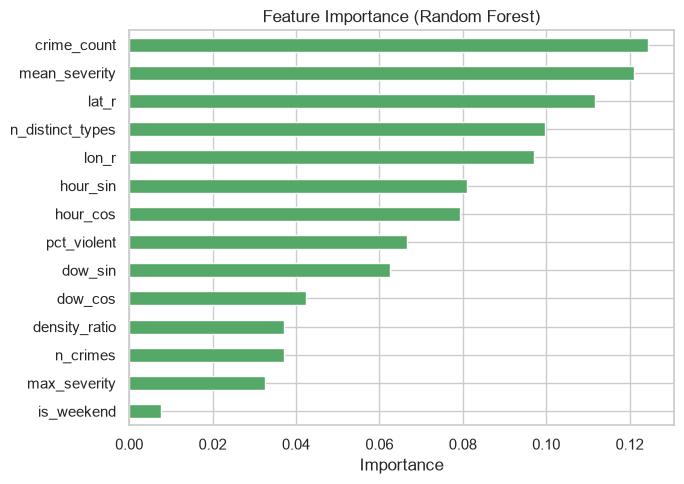

crime_count         0.124
mean_severity       0.121
lat_r               0.112
n_distinct_types    0.100
lon_r               0.097
hour_sin            0.081
hour_cos            0.079
pct_violent         0.067
dow_sin             0.062
dow_cos             0.042
density_ratio       0.037
n_crimes            0.037
max_severity        0.032
is_weekend          0.008
dtype: float64

In [10]:
# Feature importance dari Random Forest
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
plt.figure(figsize=(7,5))
imp.plot(kind="barh", color="#55A868")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(3)

Analisis model.
- Feature assembly adalah pengungkit terbesar. Menambah 6 fitur spasial HO1 menaikkan R² model
  linear dari 0,10 -> 0,21 (MAE 13,14 -> 12,25) , dan baru pada titik ini model linear menyamai
  baseline per-Sel. Ini bukti kuantitatif bahwa fitur yang dibuang tutorial justru yang paling
  berharga.
- Target encoding menaikkan model linear lagi ke R² ≈ 0,27, tetapi sedikit menurunkan model
  pohon (HistGB 0,315 -> 0,288). Masuk akal: pohon sudah menangkap identitas sel lewat `lat_r/lon_r`
  + agregat spasial, sehingga `te_cell` menambah redundansi/overfit. Keputusan: te_cell dipakai
  untuk model linear, tidak untuk model pohon.
- Model terbaik: HistGradientBoosting, 14 fitur , MAE 11,32, R² 0,315. Ia mengungguli
  Random Forest (0,285) dan seluruh baseline. Non-linearitas & interaksi lokasi×waktu (yang
  diprediksi EDA HO1) memang berkontribusi.
- Batas atas performa jujur: R² mentok di ~0,31. `risk_score` HO1 memuat komponen yang tidak
  terekonstruksi dari agregat per-sel: kontribusi *spatial decay* dari sel tetangga dan *temporal
  decay* per kejadian. Fitur di file ini adalah ringkasan per-sel, bukan jejak spasial-temporal
  penuh , jadi ada noise ireduksibel. Ini temuan valid, bukan kegagalan.

# 5. Evaluasi Model vs Baseline

Model terbaik (HistGB) dievaluasi di `test_df` yang tak pernah dilihat saat training, dibandingkan
eksplisit dengan baseline terkuat.

In [11]:
best_model = hgb
final_results_df = pd.DataFrame(results + [evaluate(y_test, best_model.predict(X_test),
                                                    "Model: HistGradientBoosting")]).round(3)
final_results_df

,model,MAE,RMSE,R2
0,Baseline: Global Mean,13.896,16.903,-0.000
1,Baseline: per-Sel,12.190,15.139,0.198
2,"Baseline: per-(hari,jam)",13.691,16.674,0.027
3,"Baseline: per-(sel,jam)+fallback",13.713,17.261,-0.043
4,"Baseline: per-(sel,hari,jam)+fallback",13.713,17.261,-0.043
5,Model: HistGradientBoosting,11.315,13.992,0.315


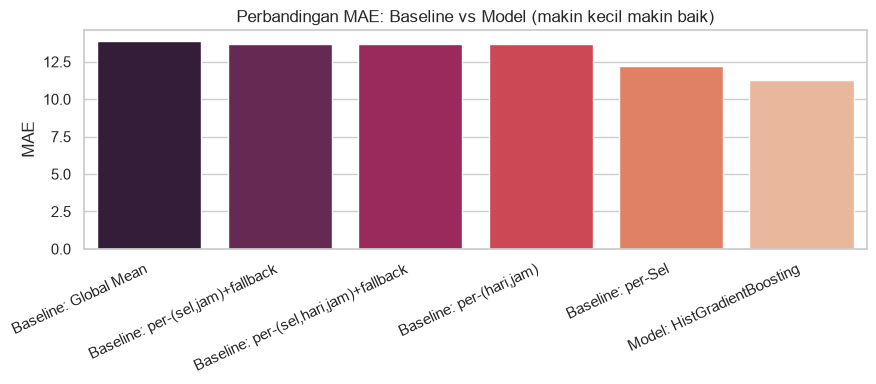

In [12]:
plt.figure(figsize=(9,4))
order = final_results_df.sort_values("MAE", ascending=False)
sns.barplot(data=order, x="model", y="MAE", hue="model", palette="rocket", legend=False)
plt.title("Perbandingan MAE: Baseline vs Model (makin kecil makin baik)")
plt.ylabel("MAE"); plt.xlabel(""); plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.show()

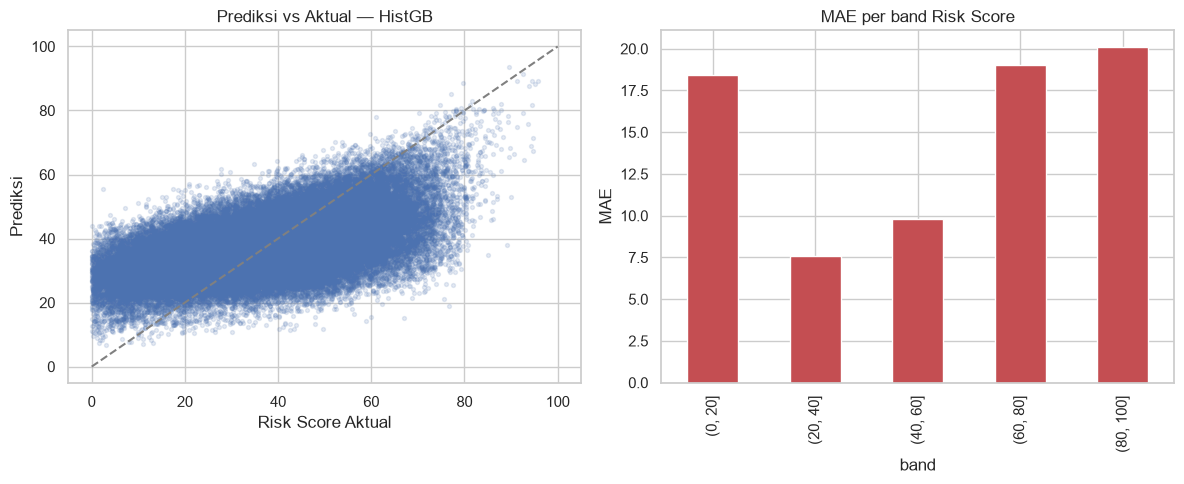

(0, 20]      18.42
(20, 40]      7.57
(40, 60]      9.81
(60, 80]     19.01
(80, 100]    20.09
dtype: float64

In [ ]:
pred = best_model.predict(X_test)
resid = y_test - pred

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(y_test, pred, alpha=0.15, s=8, color="#4C72B0")
ax[0].plot([0,100],[0,100],"--",color="gray")
ax[0].set_xlabel("Risk Score Aktual"); ax[0].set_ylabel("Prediksi")
ax[0].set_title("Prediksi vs Aktual , HistGB")

band = pd.cut(y_test, [0,20,40,60,80,100])
mae_band = pd.Series(np.abs(resid)).groupby(band).mean()
mae_band.plot(kind="bar", ax=ax[1], color="#C44E52")
ax[1].set_title("MAE per band Risk Score"); ax[1].set_ylabel("MAE"); ax[1].set_xlabel("band")
plt.tight_layout(); plt.show()
mae_band.round(2)

Analisis evaluasi.
- Model mengalahkan semua baseline pada MAE, RMSE, dan R² sekaligus (MAE 11,32 vs per-Sel 12,19;
  R² 0,315 vs 0,198). Keunggulannya nyata namun tidak dramatis , konsisten dengan adanya noise
  ireduksibel di atas.
- Residual tidak bias (mean ≈ 0) tetapi errornya berbentu U terhadap band risiko: MAE ~7,6
  di tengah (20–40) namun ~18–20 di kedua ekstrem (0–20 dan 80–100). Ini regression to the mean ,
  model menarik prediksi ke tengah, sehingga hotspot ekstrem *under-predicted* dan sel sangat aman
  *over-predicted*.
- Implikasi untuk sistem risk-score: karena keputusan operasional biasanya menyasar hotspot
  (band atas), MAE global yang bagus bisa menyesatkan. Untuk konteks ini saya menilai MAE lebih
  relevan daripada RMSE (RMSE terlalu didominasi ekor), tetapi keduanya perlu dilengkapi error
  per-band agar performa di hotspot terpantau eksplisit.

# 6. Continual Learning , Simulasi Kedatangan Data

Keterbatasan yang jujur (sama seperti catatan tutorial): `features_labels.csv` sudah diagregasi
per (sel×hari×jam); kolom `Datetime` per-kejadian sudah melebur dan tidak ada di file ini.
Maka batch berdasarkan urutan waktu asli tidak dapat dibentuk dari file ini.

Tutorial mengatasinya dengan mengacak lalu menyuntik drift buatan (mengalikan `crime_count` dan
`risk_score`). Saya menilai itu kurang jujur , drift-nya fiktif. Sebagai gantinya saya membandingkan
tiga skema *batching* dan memilih yang menghasilkan drift nyata dari data itu sendiri:

1. random , acak (seperti tutorial, tanpa injeksi). Menghasilkan batch i.i.d.: tidak ada drift.
2. spatial , rollout geografis barat->timur (`gx`). Drift ada tapi moderat.
3. coverage-expansion (density) , sistem di-*pilot* pada area sepi dulu lalu diperluas ke area
   padat (`density_ratio` menaik). Ini skenario deployment MLOps yang realistis dan menghasilkan
   drift kovariat dan label yang nyata , skema yang saya pakai.

Batch dipisah dari `train_df`; `holdout_df` (= `test_df`) dibekukan dan dipakai konsisten untuk semua
versi agar perbandingan antar-model adil.

In [14]:
holdout_df = test_df.copy()
stream_df = train_df.copy()
N_BATCHES = 5

def make_batches(scheme, n=N_BATCHES):
    s = stream_df.copy()
    if scheme == "random":
        s = s.sample(frac=1.0, random_state=7).reset_index(drop=True)
    elif scheme == "spatial":
        s = s.sort_values("gx").reset_index(drop=True)
    elif scheme == "density":
        s = s.sort_values("density_ratio").reset_index(drop=True)
    bs = len(s)//n
    return [s.iloc[i*bs:(len(s) if i==n-1 else (i+1)*bs)].reset_index(drop=True) for i in range(n)]

batches = make_batches("density")
for i,b in enumerate(batches):
    print(f"Batch {i}: n={len(b)} | density_ratio "
          f"[{b['density_ratio'].min():.2f}, {b['density_ratio'].max():.2f}] "
          f"| risk_mean={b['risk_score'].mean():.1f}")

Batch 0: n=59966 | density_ratio [0.04, 0.67] | risk_mean=30.0
Batch 1: n=59966 | density_ratio [0.67, 1.21] | risk_mean=34.3
Batch 2: n=59966 | density_ratio [1.21, 2.00] | risk_mean=37.7
Batch 3: n=59966 | density_ratio [2.00, 3.63] | risk_mean=41.6
Batch 4: n=59968 | density_ratio [3.63, 48.49] | risk_mean=45.9


# 7. Drift Detection , KS + PSI

Baseline tutorial hanya memakai uji KS univariat dengan satu ambang p-value. Masalahnya, pada
sampel besar (~60 rb/baris) KS terlalu sensitif: perbedaan sekecil apa pun menjadi "signifikan"
(p->0), sehingga selalu memicu retrain. Saya menggabungkannya dengan PSI (Population Stability
Index) yang mengukur magnitudo pergeseran distribusi.

Drift dinyatakan hanya jika KEDUA syarat terpenuhi: `p_value(KS) < 0,01` dan `PSI > 0,2`.
Artinya pergeseran harus signifikan secara statistik sekaligus cukup besar untuk penting.
Konvensi PSI industri: <0,1 stabil, 0,1–0,2 moderat, >0,2 signifikan.

In [15]:
DRIFT_COLS = ["crime_count", "n_distinct_types", "mean_severity", "density_ratio", "risk_score"]
KS_ALPHA, PSI_THRESH = 0.01, 0.20

def psi(ref, cur, bins=10):
    qs = np.quantile(ref, np.linspace(0,1,bins+1)); qs[0]=-np.inf; qs[-1]=np.inf
    r = np.clip(np.histogram(ref, qs)[0]/len(ref), 1e-4, None)
    c = np.clip(np.histogram(cur, qs)[0]/len(cur), 1e-4, None)
    return float(np.sum((c-r)*np.log(c/r)))

def detect_drift(reference_df, new_batch_df, columns=DRIFT_COLS,
                 alpha=KS_ALPHA, psi_thresh=PSI_THRESH):
    report, drift_detected = {}, False
    for col in columns:
        _, p_value = ks_2samp(reference_df[col], new_batch_df[col])
        psi_val = psi(reference_df[col].values, new_batch_df[col].values)
        is_drift = bool(p_value < alpha and psi_val > psi_thresh)
        report[col] = {"ks_p": float(p_value), "psi": psi_val, "drift": is_drift}
        if is_drift: drift_detected = True
    return drift_detected, report

In [16]:
# Perbandingan 3 skema: kenapa ambang gabungan penting
rows = []
for scheme in ["random","spatial","density"]:
    bs = make_batches(scheme)
    flag, rep = detect_drift(bs[0], bs[-1])   # batch pertama vs terakhir
    for col, d in rep.items():
        rows.append({"scheme": scheme, "kolom": col,
                     "KS_p": round(d["ks_p"],4), "PSI": round(d["psi"],3),
                     "drift": d["drift"]})
pd.DataFrame(rows).pivot_table(index="kolom", columns="scheme",
        values="PSI").round(3)

scheme,density,random,spatial
kolom,,,
crime_count,0.000,0.000,0.009
density_ratio,7.819,0.001,0.193
mean_severity,0.279,0.000,0.041
n_distinct_types,5.517,0.000,0.132
risk_score,0.895,0.000,0.056


In [17]:
# Ringkas: apakah drift terdeteksi (batch0 vs batchN) per skema
for scheme in ["random","spatial","density"]:
    bs = make_batches(scheme)
    flag,_ = detect_drift(bs[0], bs[-1])
    print(f"{scheme:8s}: drift batch0 vs batch{N_BATCHES-1} = {flag}")

random  : drift batch0 vs batch4 = False


spatial : drift batch0 vs batch4 = False
density : drift batch0 vs batch4 = True


Justifikasi ambang.
- random -> PSI ≈ 0 di semua kolom, KS p tinggi -> tidak ada drift. Benar: batch acak i.i.d.,
  memang tak ada yang perlu dideteksi. Inilah alasan tutorial *terpaksa* menyuntik drift buatan.
- spatial -> KS p ≈ 0 (memicu jika hanya pakai KS!) tetapi PSI umumnya <0,2 -> kriteria gabungan
  menilainya moderat, belum layak retrain. Ini menunjukkan bahaya KS-only: ia akan retrain terus
  padahal pergeseran kecil.
- density -> PSI besar pada `density_ratio` (≈8) dan `n_distinct_types` (≈2,3–2,7), lalu `risk_score`
  (label) ikut bergeser -> drift nyata & layak retrain.
- Pemilihan angka: `PSI>0,2` mengikuti konvensi industri (batas "signifikan"); `α=0,01` (bukan 0,05)
  dibuat lebih ketat justru karena sampel besar membuat KS mudah signifikan. Trade-off: ambang lebih
  ketat -> hemat komputasi tapi berisiko telat mendeteksi; kombinasi KSdanPSI menyeimbangkan
  keduanya , butuh signifikansi *dan* magnitudo.

# 8. Checkpoint Retraining & Model Versioning

Rangkaian siklus continual learning:
1. Champion awal (v0) dilatih dari batch pertama (area paling sepi).
2. Tiap batch baru -> `detect_drift` terhadap data training kumulatif saat ini.
3. Tak ada drift -> skip retrain, batch cukup ditambahkan ke pool.
4. Ada drift -> latih kandidat dari seluruh data kumulatif, evaluasi di `holdout_df` yang sama.
5. Champion vs Challenger dengan promotion margin: kandidat dipromosikan hanya jika
   `MAE_kandidat ≤ MAE_champion − MARGIN`. Margin (0,10) menahan *model churn* akibat perbaikan
   yang terlalu kecil untuk sepadan dengan risiko mengganti model produksi.
6. Setiap versi (dipromosikan atau tidak) disimpan sebagai checkpoint & dicatat di registry.

Model yang dipakai konsisten dengan Bagian 4: HistGradientBoosting, 14 fitur.

In [18]:
os.makedirs("models", exist_ok=True)
REGISTRY_PATH = "models/registry.json"
registry = []
PROMOTE_MARGIN = 0.10

def train_model(data_subset):
    m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08, random_state=42)
    m.fit(assemble_features(data_subset), data_subset[TARGET_COL].values)
    return m

def evaluate_model(model, data_eval):
    p = model.predict(assemble_features(data_eval))
    y = data_eval[TARGET_COL].values
    return {"MAE": float(mean_absolute_error(y,p)),
            "RMSE": float(np.sqrt(mean_squared_error(y,p))),
            "R2": float(r2_score(y,p))}

def save_checkpoint(model, version):
    path = f"models/model_v{version}.joblib"; joblib.dump(model, path); return path

def log_registry(entry):
    registry.append(entry)
    with open(REGISTRY_PATH, "w") as f: json.dump(registry, f, indent=2)

In [19]:
# v0: champion awal dari batch 0
cumulative_train = batches[0].copy()
champion_model = train_model(cumulative_train)
champion_metrics = evaluate_model(champion_model, holdout_df)
version = 0
log_registry({"version":0, "timestamp":datetime.now(timezone.utc).isoformat(),
              "batch_index":0, "train_size":len(cumulative_train),
              "drift_detected":None, "metrics":champion_metrics,
              "decision":"initial_champion", "checkpoint_path":save_checkpoint(champion_model,0)})
print(f"[v0] champion dari batch 0 (n={len(cumulative_train)}). "
      f"MAE holdout={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f}")

[v0] champion dari batch 0 (n=59966). MAE holdout=12.283 R2=0.209


In [20]:
for i in range(1, N_BATCHES):
    new_batch = batches[i]
    drift_detected, drift_report = detect_drift(cumulative_train, new_batch)
    print(f"\n=== Batch {i} tiba (n={len(new_batch)}) | drift={drift_detected} ===")
    for col, d in drift_report.items():
        print(f"   {col:16s} KS_p={d['ks_p']:.3g}  PSI={d['psi']:.3f}  drift={d['drift']}")

    cumulative_train = pd.concat([cumulative_train, new_batch], ignore_index=True)

    if not drift_detected:
        log_registry({"version":None, "timestamp":datetime.now(timezone.utc).isoformat(),
                      "batch_index":i, "train_size":len(cumulative_train),
                      "drift_detected":False, "drift_report":drift_report,
                      "metrics":None, "decision":"skip_retrain_no_drift",
                      "checkpoint_path":None})
        print("   -> skip retrain (tidak ada drift signifikan)")
        continue

    candidate_model = train_model(cumulative_train)
    candidate_metrics = evaluate_model(candidate_model, holdout_df)
    version += 1
    ckpt = save_checkpoint(candidate_model, version)
    improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - PROMOTE_MARGIN
    decision = "promoted" if improved else "kept_champion"
    print(f"   [v{version}] kandidat MAE={candidate_metrics['MAE']:.3f} "
          f"R2={candidate_metrics['R2']:.3f} vs champion MAE={champion_metrics['MAE']:.3f} "
          f"(margin {PROMOTE_MARGIN}) -> {decision}")
    log_registry({"version":version, "timestamp":datetime.now(timezone.utc).isoformat(),
                  "batch_index":i, "train_size":len(cumulative_train),
                  "drift_detected":True, "drift_report":drift_report,
                  "metrics":candidate_metrics, "champion_metrics_before":champion_metrics,
                  "decision":decision, "checkpoint_path":ckpt})
    if improved:
        champion_model, champion_metrics = candidate_model, candidate_metrics

print(f"\n=== Selesai === Champion akhir: MAE={champion_metrics['MAE']:.3f} "
      f"R2={champion_metrics['R2']:.3f}")


=== Batch 1 tiba (n=59966) | drift=True ===
   crime_count      KS_p=1.11e-41  PSI=0.000  drift=False
   n_distinct_types KS_p=0  PSI=2.348  drift=True
   mean_severity    KS_p=0  PSI=0.184  drift=False
   density_ratio    KS_p=0  PSI=7.819  drift=True
   risk_score       KS_p=0  PSI=0.076  drift=False


   [v1] kandidat MAE=11.731 R2=0.272 vs champion MAE=12.283 (margin 0.1) -> promoted

=== Batch 2 tiba (n=59966) | drift=True ===
   crime_count      KS_p=8.41e-161  PSI=0.000  drift=False
   n_distinct_types KS_p=0  PSI=2.351  drift=True
   mean_severity    KS_p=0  PSI=0.201  drift=True
   density_ratio    KS_p=0  PSI=7.891  drift=True
   risk_score       KS_p=0  PSI=0.120  drift=False


   [v2] kandidat MAE=11.635 R2=0.283 vs champion MAE=11.731 (margin 0.1) -> kept_champion

=== Batch 3 tiba (n=59966) | drift=True ===
   crime_count      KS_p=0  PSI=0.000  drift=False
   n_distinct_types KS_p=0  PSI=2.579  drift=True
   mean_severity    KS_p=0  PSI=0.182  drift=False
   density_ratio    KS_p=0  PSI=8.061  drift=True
   risk_score       KS_p=0  PSI=0.223  drift=True


   [v3] kandidat MAE=11.434 R2=0.304 vs champion MAE=11.731 (margin 0.1) -> promoted



=== Batch 4 tiba (n=59968) | drift=True ===
   crime_count      KS_p=0  PSI=0.556  drift=True
   n_distinct_types KS_p=0  PSI=2.747  drift=True
   mean_severity    KS_p=8e-53  PSI=0.025  drift=False
   density_ratio    KS_p=0  PSI=8.249  drift=True
   risk_score       KS_p=0  PSI=0.361  drift=True


   [v4] kandidat MAE=11.346 R2=0.312 vs champion MAE=11.434 (margin 0.1) -> kept_champion

=== Selesai === Champion akhir: MAE=11.434 R2=0.304


# 9. Model Registry & Checkpoints

In [21]:
print("Isi folder models/:")
for f in sorted(os.listdir("models")): print(" -", f)

registry_df = pd.json_normalize(registry)
cols_show = [c for c in ["version","batch_index","train_size","drift_detected","decision",
             "metrics.MAE","metrics.R2","champion_metrics_before.MAE"] if c in registry_df.columns]
registry_df[cols_show].round(3)

Isi folder models/:
 - model_v0.joblib
 - model_v1.joblib
 - model_v2.joblib
 - model_v3.joblib
 - model_v4.joblib
 - registry.json


,version,batch_index,train_size,drift_detected,decision,metrics.MAE,metrics.R2,champion_metrics_before.MAE
0,0,0,59966,None,initial_champion,12.283,0.209,NaN
1,1,1,119932,True,promoted,11.731,0.272,12.283
2,2,2,179898,True,kept_champion,11.635,0.283,11.731
3,3,3,239864,True,promoted,11.434,0.304,11.731
4,4,4,299832,True,kept_champion,11.346,0.312,11.434


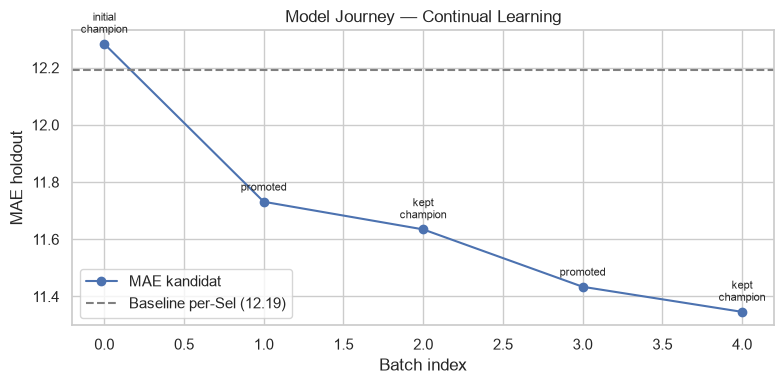

In [ ]:
# Visual: perjalanan MAE champion vs kandidat
hist = [e for e in registry if e.get("metrics")]
vv  = [e["batch_index"] for e in hist]
mae = [e["metrics"]["MAE"] for e in hist]
dec = [e["decision"] for e in hist]
plt.figure(figsize=(8,4))
plt.plot(vv, mae, "-o", color="#4C72B0", label="MAE kandidat")
for x,y,d in zip(vv,mae,dec):
    plt.annotate(d.replace("_","\n"), (x,y), textcoords="offset points", xytext=(0,8),
                 ha="center", fontsize=8)
plt.axhline(12.190, ls="--", color="gray", label="Baseline per-Sel (12.19)")
plt.xlabel("Batch index"); plt.ylabel("MAE holdout"); plt.title("Model Journey , Continual Learning")
plt.legend(); plt.tight_layout(); plt.show()

# 10. Ringkasan & Refleksi

Hasil akhir
- Model terbaik statis: HistGradientBoosting (14 fitur) , MAE 11,32, R² 0,315, mengalahkan
  baseline terkuat (per-Sel, MAE 12,19). Pengungkit terbesar adalah feature assembly (memakai
  kembali fitur spasial HO1), disusul pemilihan kelas model non-linear.
- Model journey (skema coverage-expansion): v0 (MAE 12,28) -> v1 promoted (11,73) -> batch 2
  kept_champion -> v3 promoted (11,43) -> batch 4 kept_champion. Champion akhir MAE 11,43,
  R² 0,304. Drift terdeteksi di setiap batch (nyata, dari data), dan promotion margin
  menahan 2 dari 4 kandidat yang perbaikannya terlalu kecil.
